# 智能客服（chatbot）实战

## 1.运行和测试第 1 部分的聊天机器人（ChatBot-Only），并尝试找到一个其无法回答正确的事实性问题。

In [1]:
import os

# 开启 LangSmith 跟踪，便于调试和查看详细执行信息
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ChatBot"

In [2]:
os.getenv("GLM_BASE_URL")

'https://open.bigmodel.cn/api/paas/v4/'

In [25]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# 定义状态类型，继承自 TypedDict，并使用 add_messages 函数将消息追加到现有列表
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 创建一个状态图对象，传入状态定义
graph_builder = StateGraph(State)

In [26]:
type(add_messages)

function

In [27]:
from langchain_openai import ChatOpenAI

# 初始化一个 GPT-4o-mini 模型
chat_model = ChatOpenAI(model="glm-4-plus", api_key=os.getenv("GLM_API_KEY"), base_url=os.getenv("GLM_BASE_URL"))

# 定义聊天机器人的节点函数，接收当前状态并返回更新的消息列表
def chatbot(state: State):
    # print(state["messages"])
    return {"messages": [chat_model.invoke(state["messages"])]}

# 第一个参数是唯一的节点名称，第二个参数是每次节点被调用时的函数或对象
graph_builder.add_node("chatbot", chatbot)

In [28]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

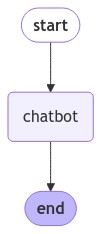

In [29]:
# 编译状态图并生成可执行图对象
graph = graph_builder.compile()

# 你可以使用 get_graph 方法来可视化图，并结合 draw 方法（如 draw_ascii 或 draw_png）
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [30]:
# 开始一个简单的聊天循环
while True:
    # 获取用户输入
    user_input = input("User: ")
    
    # 可以随时通过输入 "quit"、"exit" 或 "q" 退出聊天循环
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")  # 打印告别信息
        break  # 结束循环，退出聊天

    # 将每次用户输入的内容传递给 graph.stream，用于聊天机器人状态处理
    # "messages": ("user", user_input) 表示传递的消息是用户输入的内容
    for event in graph.stream({"messages": ("user", user_input)}):
        
        # 遍历每个事件的值
        for value in event.values():
            # 打印输出 chatbot 生成的最新消息
            print("Assistant:", value["messages"][-1].content)

User:  2024年奥运会哪个国家的金牌数量最多，获得了几枚？


Assistant: 截至我知识更新的时间点（2023年），2024年奥运会的具体金牌分布情况尚未揭晓，因为该赛事尚未举行。2024年夏季奥运会计划在法国巴黎举行。

通常，奥运会金牌数量的统计会在赛事结束后由国际奥委会（IOC）和相关体育组织正式公布。因此，要获取2024年奥运会哪个国家金牌数量最多以及具体获得了多少枚金牌的信息，您需要在赛事结束后查阅官方统计数据或关注相关新闻报道。

如果您在2024年奥运会结束后需要这一信息，建议查阅权威新闻媒体或国际奥委会的官方公告。


User:  q


Goodbye!


In [31]:
type(graph)

langgraph.graph.state.CompiledStateGraph

## 2.使用联网查询工具（如：Tavily），在第 2 部分的聊天机器人（ChatBot + Tool）上测试相同问题，并对比生成结果。

In [33]:
from langchain_community.tools.tavily_search import TavilySearchResults

# 定义 Tavily 搜索工具，最大搜索结果数设置为 2
tool = TavilySearchResults(max_results=2)
tools = [tool]

# 测试工具调用
tool.invoke("2024年奥运会哪个国家的金牌数量最多，获得了几枚？")

[{'url': 'https://news.qq.com/rain/a/20240812A05FA000',
  'content': '巴黎奥运会最终金牌榜，中国与美国并列第一！附40枚金牌项目分布_腾讯新闻 更多 正在浏览：巴黎奥运会最终金牌榜，中国与美国并列第一！附40枚金牌项目分布 晚池 搜索 游戏 无障碍浏览 快捷访问 登录 +关注 评论 收藏 复制链接 微信好友 用微信扫描二维码 QQ好友 用QQ扫描二维码 手机看 微信扫一扫，随时随地看 问新闻妹 巴黎奥运会最终金牌榜，中国与美国并列第一！附40枚金牌项目分布 晚池2024-08-12 15:43发布于辽宁体育领域创作者 +关注 巴黎奥运会最终金牌榜，中国与美国并列第一，附40枚金牌项目分布 2024年巴黎奥运会所有比赛项目都已经结束，中国体育代表团获得40枚金牌、27枚银牌、24枚铜牌，与美国体育代表团（40金44银42铜）并列最终金牌榜首位。奖牌榜上，获得91枚奖牌的中国排在获得126枚奖牌的美国之后，位列次席。 本届奥运会上，中国代表团的金牌数超过了2012年伦敦奥运会（39金31银22铜，共92枚奖牌），创造了中国代表团在境外奥运会的金牌数纪录！金牌数仅少于2008年北京奥运会（48金22银30铜，共100枚奖牌）。 巴黎奥运会金牌榜前十名如下，小日本、澳大利亚和东道主法国排名第三、第四和第五。 中国体育代表团的金牌分布于14个项目，在乒乓球、跳水和花样游泳三个项目上包揽全部金牌。在射击和举重等传统优势项目上继续保持强势。 中国体育代表团金牌项目分布如下！ 射击：5金 混合团体10米气步枪：黄雨婷，盛李豪。第1金（晚池注：按照夺金时间顺序，中国体育代表团夺得的第1枚金牌）。 男子10米气手枪：谢瑜。第3金。 男子10米气步枪：盛李豪。第4金。 男子50米步枪三姿：刘宇坤。第9金。 男子25米手枪速射：李越宏。第19金。 跳水：8金（包揽） 女子双人3米跳板：昌雅妮，陈艺文。第2金。 男子双人10米跳台：练俊杰，杨昊。第5金。 女子双人10米跳台：全红婵，陈芋汐。第7金。 男子双人3米跳板：王宗源，龙道一。第12金。 女子10米跳台：全红婵。第22金。 男子3米跳板：谢思埸。第25金。 女子3米跳板：陈艺文。第31金。 男子10米跳台：曹缘。第36金。 乒乓球：5金（包揽） 混合双打：王楚钦，孙

In [34]:
tool.name

'tavily_search_results_json'

In [42]:
from typing import Annotated
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

# 定义状态
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# 初始化 LLM 并绑定搜索工具
chat_model = ChatOpenAI(model="glm-4-plus", api_key=os.getenv("GLM_API_KEY"), base_url=os.getenv("GLM_BASE_URL"))
llm_with_tools = chat_model.bind_tools(tools)

# 更新聊天机器人节点函数，支持工具调用
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# 将更新后的节点添加到状态图中
graph_builder.add_node("chatbot", chatbot)

In [43]:
import json
from langchain_core.messages import ToolMessage

# 定义 BasicToolNode，用于执行工具请求
class BasicToolNode:
    """一个在最后一条 AIMessage 中执行工具请求的节点。
    
    该节点会检查最后一条 AI 消息中的工具调用请求，并依次执行这些工具调用。
    """

    def __init__(self, tools: list) -> None:
        # tools 是一个包含所有可用工具的列表，我们将其转化为字典，
        # 通过工具名称（tool.name）来访问具体的工具
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        """执行工具调用
        
        参数:
        inputs: 包含 "messages" 键的字典，"messages" 是对话消息的列表，
                其中最后一条消息可能包含工具调用的请求。
        
        返回:
        包含工具调用结果的消息列表
        """
        # 获取消息列表中的最后一条消息，判断是否包含工具调用请求
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("输入中未找到消息")

        # 用于保存工具调用的结果
        outputs = []

        # 遍历工具调用请求，执行工具并将结果返回
        for tool_call in message.tool_calls:
            # 根据工具名称找到相应的工具，并调用工具的 invoke 方法执行工具
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            # 将工具调用结果作为 ToolMessage 保存下来
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),  # 工具调用的结果以 JSON 格式保存
                    name=tool_call["name"],  # 工具的名称
                    tool_call_id=tool_call["id"],  # 工具调用的唯一标识符
                )
            )
        # 返回包含工具调用结果的消息
        return {"messages": outputs}

In [44]:
# 将 BasicToolNode 添加到状态图中
tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

In [45]:
from typing import Literal

# 定义路由函数，检查工具调用
def route_tools(
    state: State,
) -> Literal["tools", "__end__"]:
    """
    使用条件边来检查最后一条消息中是否有工具调用。
    
    参数:
    state: 状态字典或消息列表，用于存储当前对话的状态和消息。
    
    返回:
    如果最后一条消息包含工具调用，返回 "tools" 节点，表示需要执行工具调用；
    否则返回 "__end__"，表示直接结束流程。
    """
    # 检查状态是否是列表类型（即消息列表），取最后一条 AI 消息
    if isinstance(state, list):
        ai_message = state[-1]
    # 否则从状态字典中获取 "messages" 键，取最后一条消息
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    # 如果没有找到消息，则抛出异常
    else:
        raise ValueError(f"输入状态中未找到消息: {state}")

    # 检查最后一条消息是否有工具调用请求
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"  # 如果有工具调用请求，返回 "tools" 节点
    return "__end__"  # 否则返回 "__end__"，流程结束

# 添加条件边，判断是否需要调用工具
graph_builder.add_conditional_edges(
    "chatbot",  # 从聊天机器人节点开始
    route_tools,  # 路由函数，决定下一个节点
    {
        "tools": "tools", 
        "__end__": "__end__"
    },  # 定义条件的输出，工具调用走 "tools"，否则走 "__end__"
)

# 当工具调用完成后，返回到聊天机器人节点以继续对话
graph_builder.add_edge("tools", "chatbot")

# 指定从 START 节点开始，进入聊天机器人节点
graph_builder.add_edge(START, "chatbot")

In [46]:
# 编译状态图，生成可执行的流程图
graph = graph_builder.compile()

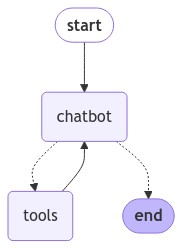

In [47]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [49]:
from langchain_core.messages import BaseMessage

# 进入一个无限循环，用于模拟持续的对话
while True:
    # 获取用户输入
    user_input = input("User: ")
    
    # 如果用户输入 "quit"、"exit" 或 "q"，则退出循环，结束对话
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")  # 打印告别语
        break  # 退出循环

    # 使用 graph.stream 处理用户输入，并生成机器人的回复
    # "messages" 列表中包含用户的输入，传递给对话系统
    for event in graph.stream({"messages": [("user", user_input)]}):
        
        # 遍历 event 的所有值，检查是否是 BaseMessage 类型的消息
        for value in event.values():
            if isinstance(value["messages"][-1], BaseMessage):
                # 如果消息是 BaseMessage 类型，则打印机器人的回复
                print("Assistant:", value["messages"][-1].content)

User:  2024年奥运会哪个国家的金牌数量最多，获得了几枚？


Assistant: 
Assistant: [{"url": "https://baike.baidu.com/item/2024\u5e74\u5df4\u9ece\u5965\u8fd0\u4f1a\u5956\u724c\u699c/64375363", "content": "2024\u5e74\u5df4\u9ece\u5965\u8fd0\u4f1a\u5956\u724c\u699c\uff0c\u5217\u51fa2024\u5e747\u670826\u65e5\u81f38\u670811\u65e5\u5728\u6cd5\u56fd\u5df4\u9ece\u4e3e\u529e\u7684\u7b2c33\u5c4a\u590f\u5b63\u5965\u6797\u5339\u514b\u8fd0\u52a8\u4f1a\u5168\u90e8\u6bd4\u8d5b\u9879\u76ee\u7684\u91d1\u3001\u94f6\u3001\u94dc\u724c\u5f97\u4e3b\uff0c\u8bb0\u5f55\u5404\u53c2\u8d5b\u961f\u4f0d\u6240\u83b7\u5f97\u5956\u724c\u679a\u6570\u3002\u672c\u5c4a\u5965\u8fd0\u4f1a\u5956\u724c\u7531\u6cd5\u56fd\u8457\u540d\u8bbe\u8ba1\u5e08\u83f2\u5229\u666e\u00b7\u65af\u5854\u514b\u8bbe\u8ba1\uff0c\u6bcf\u4e00\u679a\u5956\u724c\u4e0a\u90fd\u88c5\u9970\u6709\u4e00\u5757\u5177\u6709\u8c61\u5f81\u610f\u4e49\u7684\u91d1\u5c5e\u2014\u2014\u5f53\u5e74\u7528\u4e8e\u5efa\u9020\u57c3\u83f2\u5c14\u94c1\u5854"}, {"url": "https://www.bbc.com/zhongwen/simp/world-69210979", "content": "\u

User:  2024年奥运会哪个国家的金牌数量最多，获得了几枚？


Assistant: 
Assistant: [{"url": "https://news.qq.com/rain/a/20240812A05FA000", "content": "\u5df4\u9ece\u5965\u8fd0\u4f1a\u6700\u7ec8\u91d1\u724c\u699c\uff0c\u4e2d\u56fd\u4e0e\u7f8e\u56fd\u5e76\u5217\u7b2c\u4e00\uff01\u964440\u679a\u91d1\u724c\u9879\u76ee\u5206\u5e03_\u817e\u8baf\u65b0\u95fb \u66f4\u591a \u6b63\u5728\u6d4f\u89c8\uff1a\u5df4\u9ece\u5965\u8fd0\u4f1a\u6700\u7ec8\u91d1\u724c\u699c\uff0c\u4e2d\u56fd\u4e0e\u7f8e\u56fd\u5e76\u5217\u7b2c\u4e00\uff01\u964440\u679a\u91d1\u724c\u9879\u76ee\u5206\u5e03 \u665a\u6c60 \u641c\u7d22 \u6e38\u620f \u65e0\u969c\u788d\u6d4f\u89c8 \u5feb\u6377\u8bbf\u95ee \u767b\u5f55 +\u5173\u6ce8 \u8bc4\u8bba \u6536\u85cf \u590d\u5236\u94fe\u63a5 \u5fae\u4fe1\u597d\u53cb \u7528\u5fae\u4fe1\u626b\u63cf\u4e8c\u7ef4\u7801 QQ\u597d\u53cb \u7528QQ\u626b\u63cf\u4e8c\u7ef4\u7801 \u624b\u673a\u770b \u5fae\u4fe1\u626b\u4e00\u626b\uff0c\u968f\u65f6\u968f\u5730\u770b \u95ee\u65b0\u95fb\u59b9 \u5df4\u9ece\u5965\u8fd0\u4f1a\u6700\u7ec8\u91d1\u724c\u699c\uff0c\u4e2d\u5

User:  q


Goodbye!
